# ```Consistency Validation Between Source and Index```

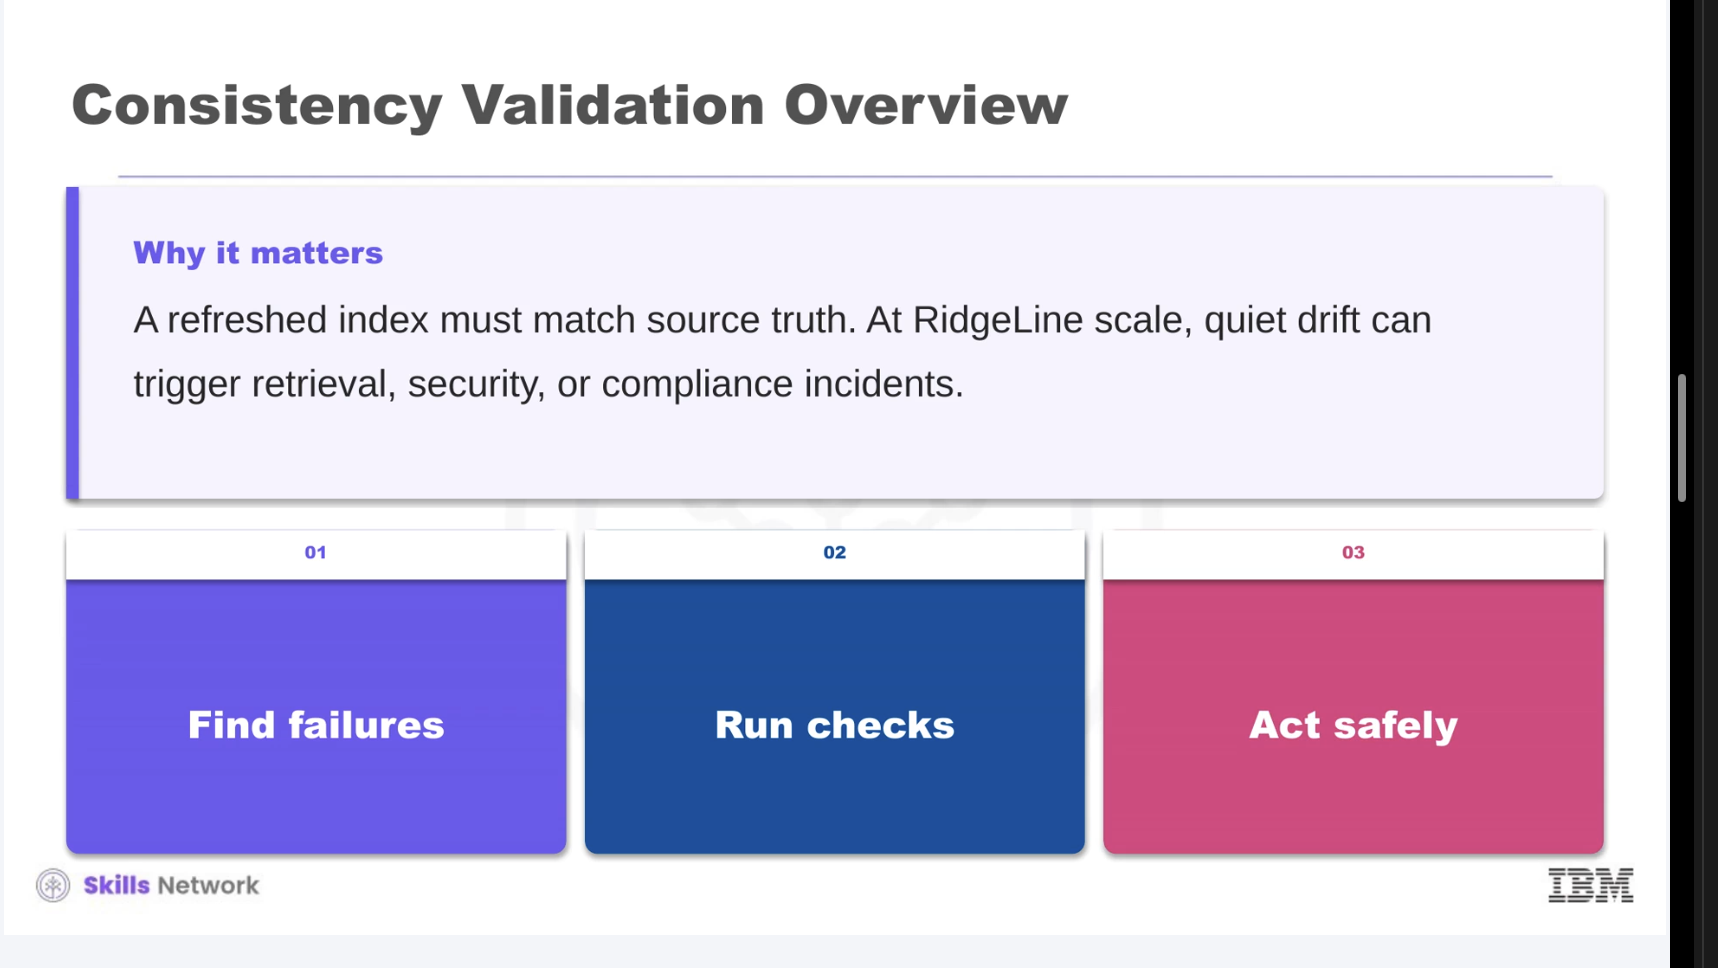
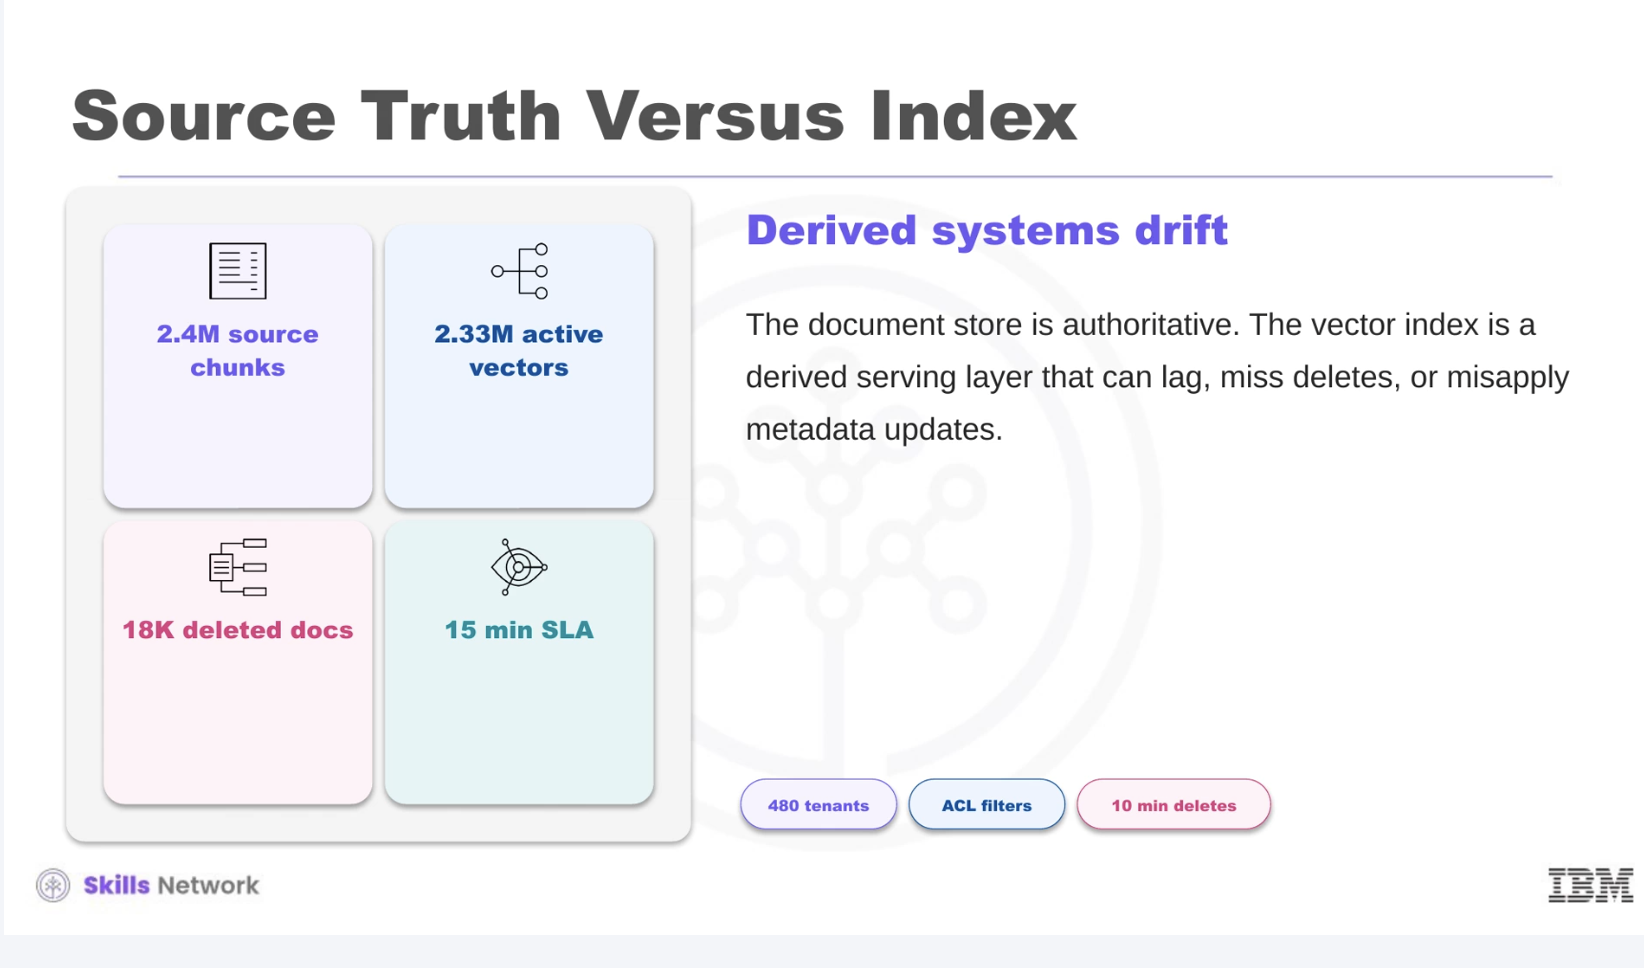
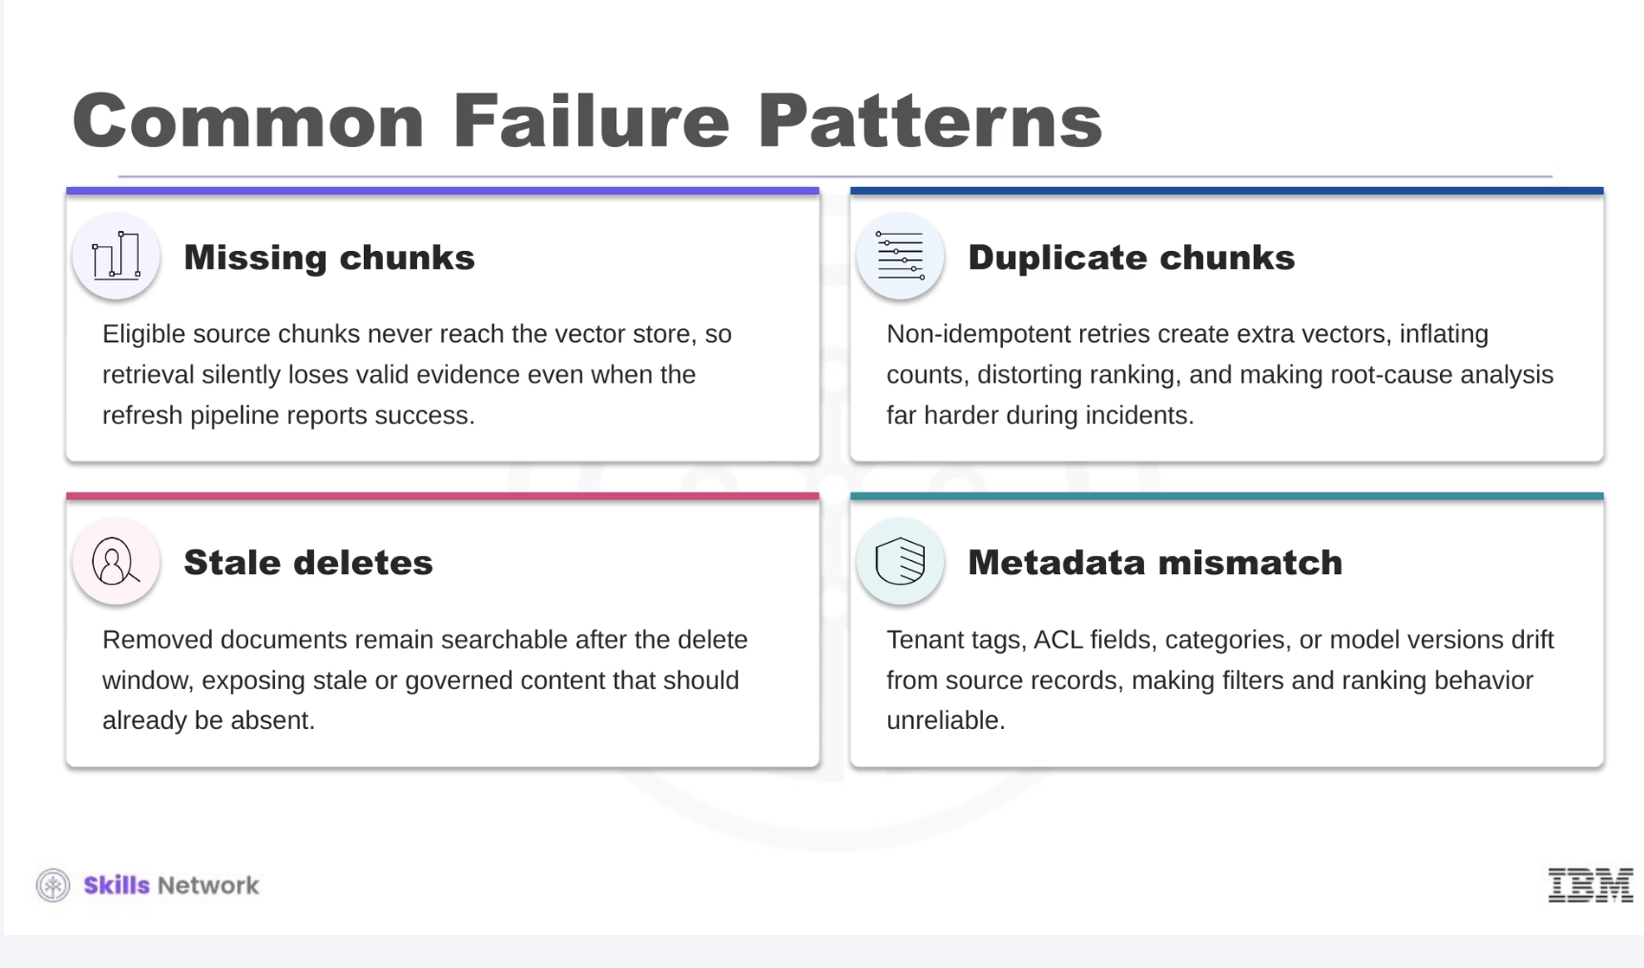
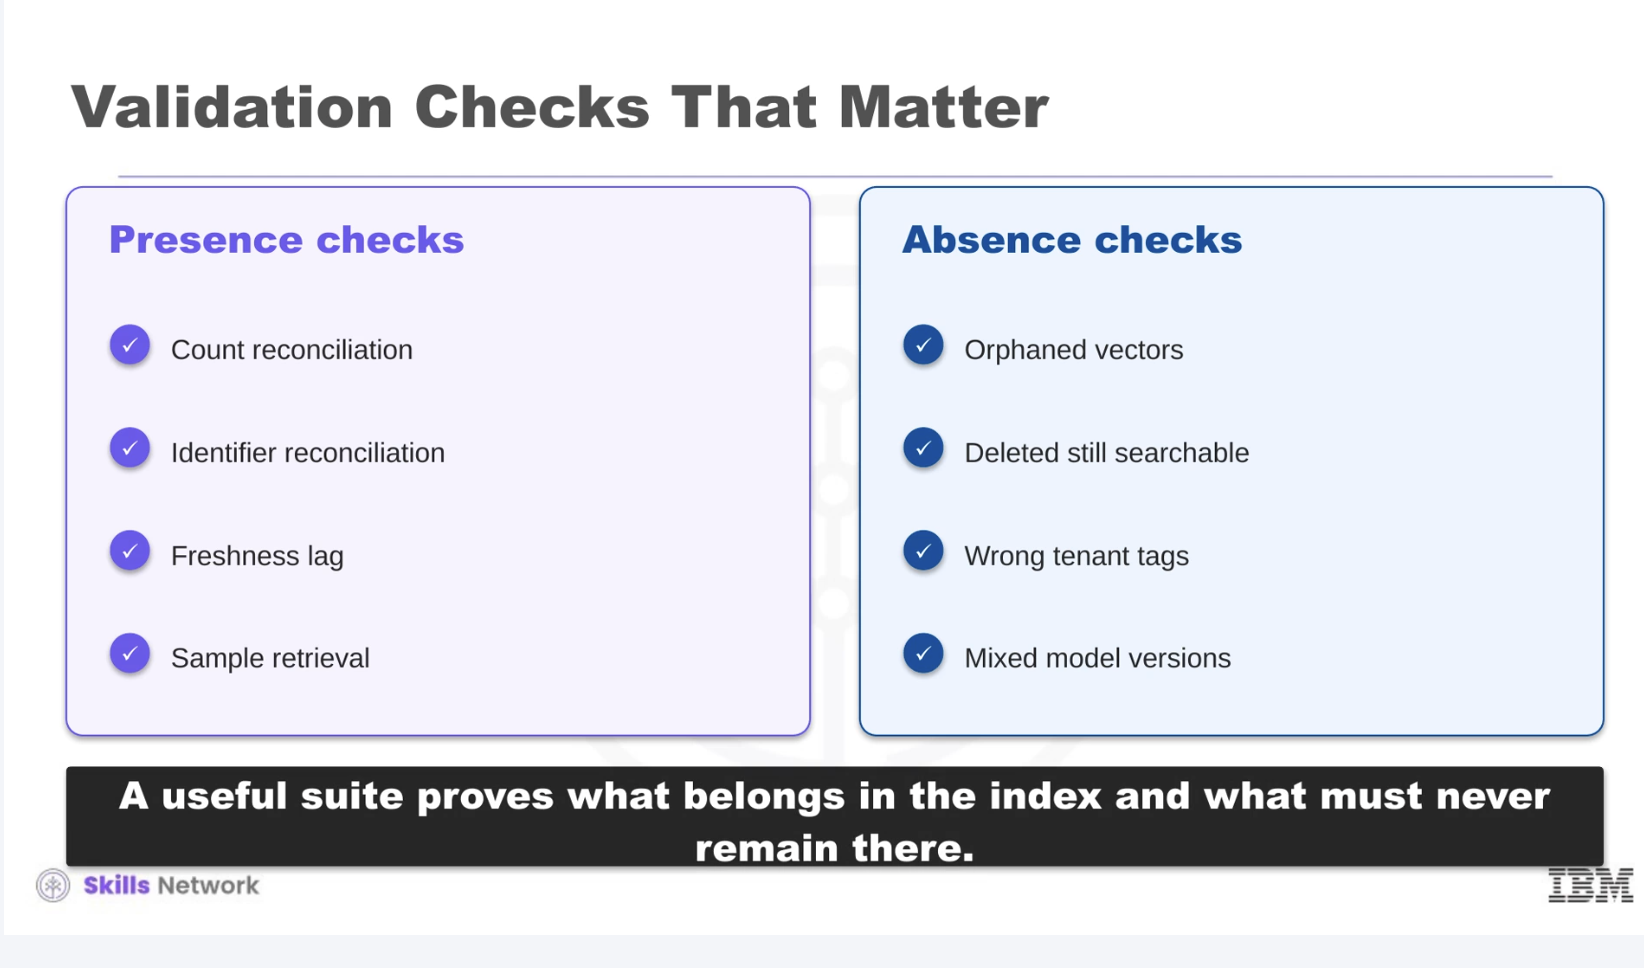
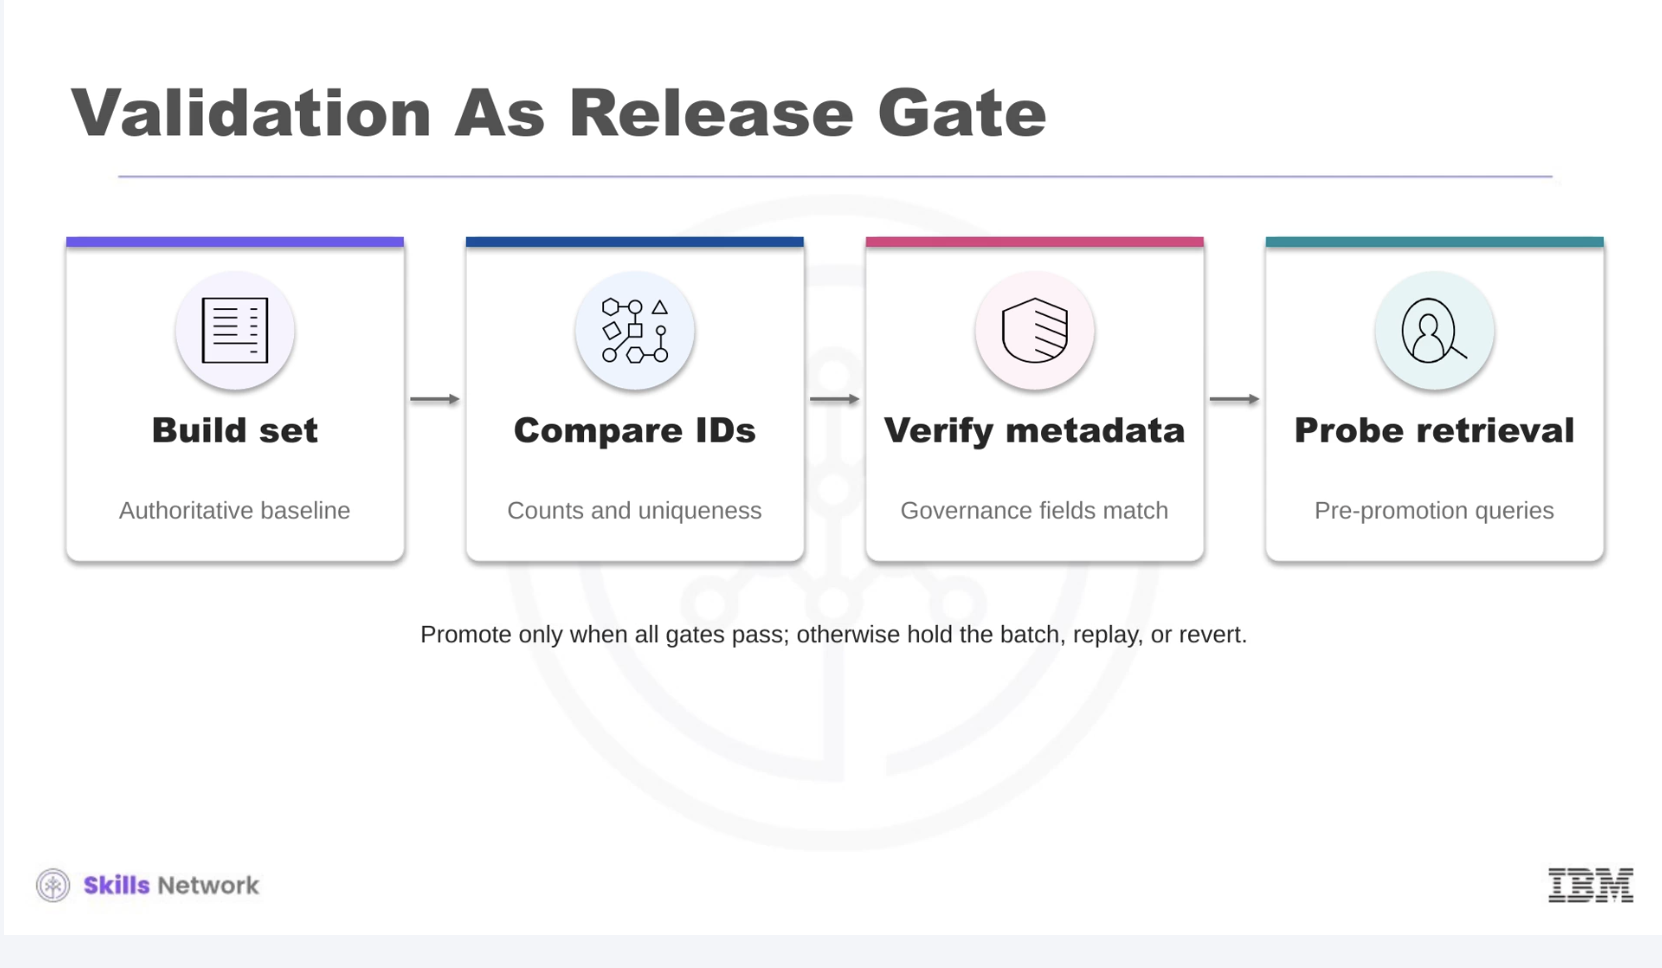
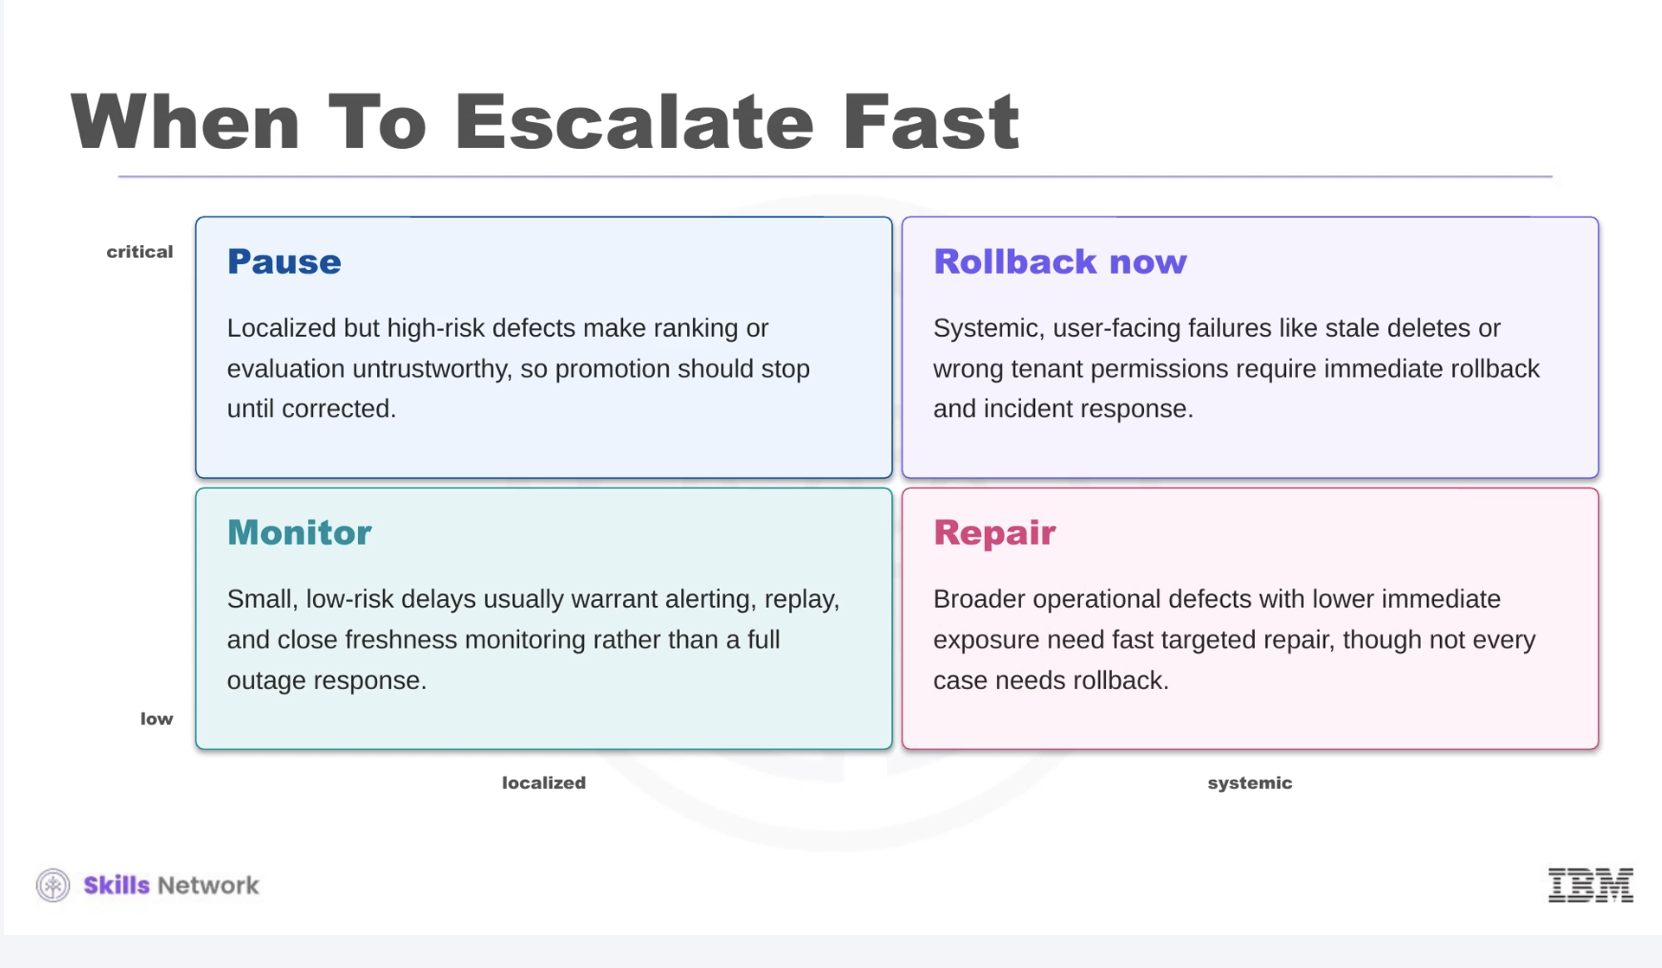
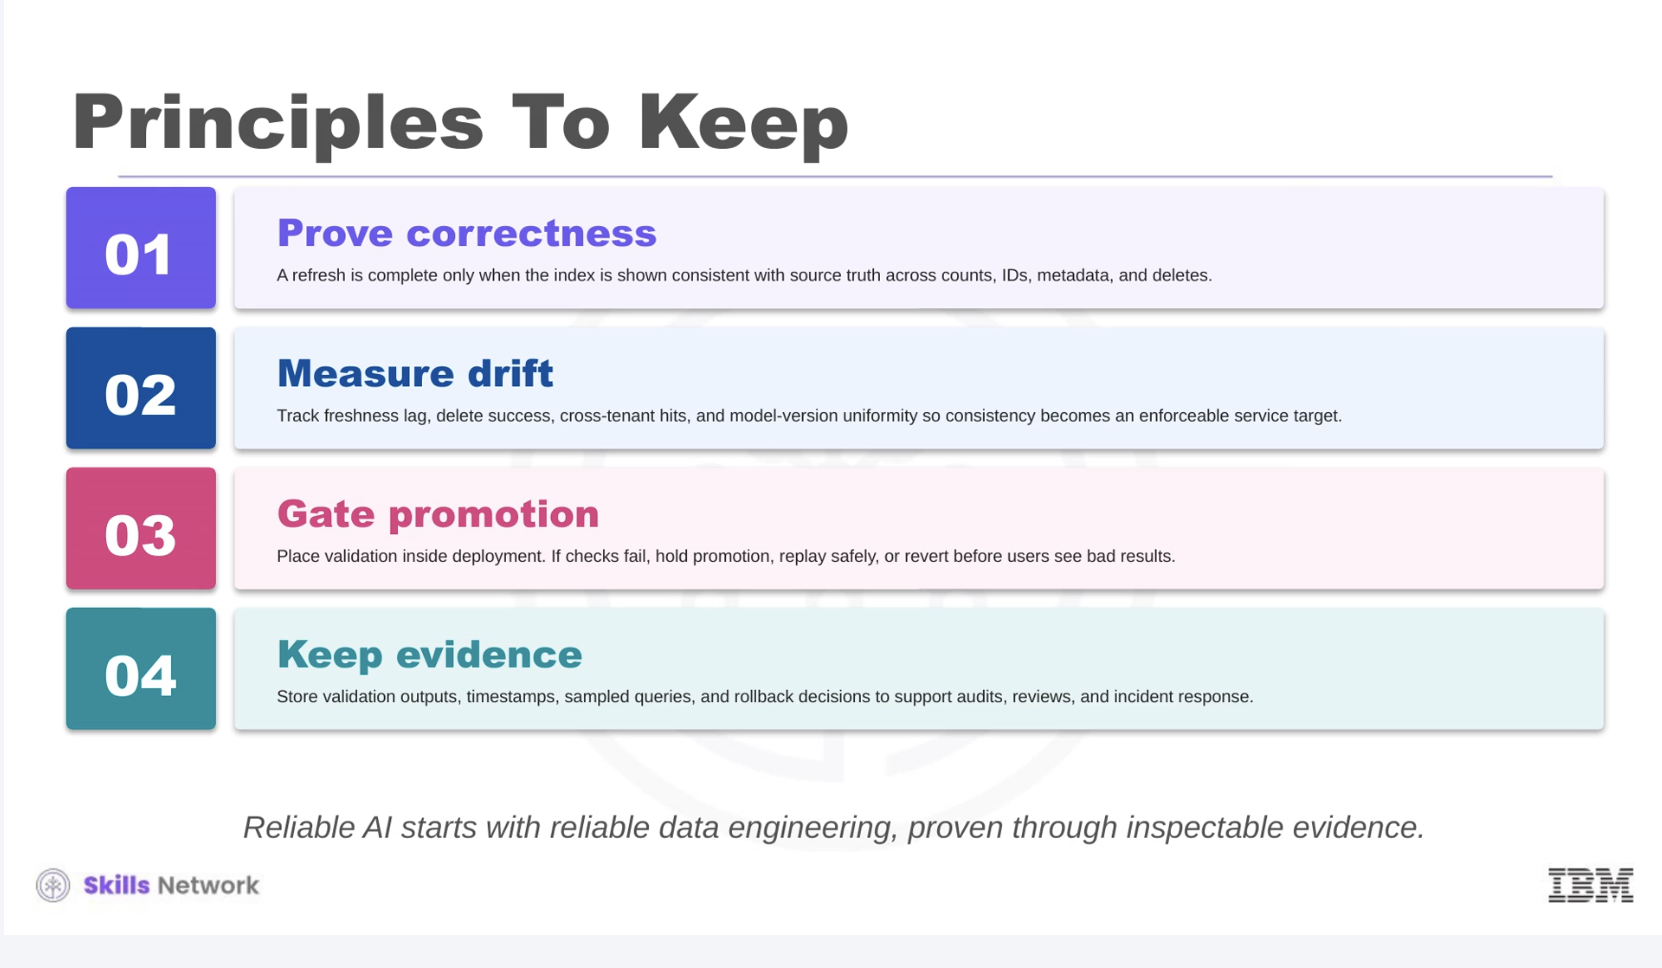


 # (Change Data Capture)  ```CDC = the notification system for changes in your source data.```

# Freshness, Idempotency & SLAs/SLOs for the Vector Index

> 💡 **Core lesson:** Don't just make the refresh job run. Make the index **converge to source truth**, **measure** how quickly it does so, make **retries safe**, and have **evidence** when something goes wrong.

---

## 0. Where This Chapter Fits

| Chapter | Question it asks |
|---|---|
| Previous chapter | How do I update the vector index correctly? |
| This chapter | How do I know the index is actually keeping up, and what happens when the update process fails? |

The three big ideas are:

```
FRESHNESS
    ↓
How quickly does source truth reach the index?

IDEMPOTENCY
    ↓
Can I safely retry failed work?

SLA / SLO
    ↓
Can I measure and prove that the system is meeting its promises?
```

The chapter explicitly frames freshness as a **measurable lag**, idempotency as **safe retry behavior**, and SLAs/SLOs as **operational commitments**.

---

## 1. 🔴 Freshness Is a Contract

This is the first thing I need to understand.

Suppose:

```
Source document changed
        ↓
      9:03 AM
```

But the vector DB doesn't reflect it until:

```
      9:17 AM
```

| Event | Time |
|---|---|
| Source changed | 9:03 AM |
| Index updated | 9:17 AM |
| **Freshness lag** | **14 minutes** |

The chapter defines it simply as:

```
Freshness lag =
index availability timestamp
-
source change timestamp
```

So:

```
Source changes
     │
     │  14 min
     ↓
Index updated
```

> 📌 That's not just an engineering detail. **It's a contract.**

---

## 2. Why "Refresh Every 6 Hours" Is a Bad Universal Rule

Imagine I have four types of changes:

| Change | Example target |
|---|---|
| Low-risk documentation | ≤24 hours |
| Product documentation | ≤4 hours |
| Permission restriction | ≤10 minutes |
| Delete | As soon as feasible |

The chapter gives these different freshness expectations because **the risk is different**.

### Normal documentation

Someone changes:

> "Our office is located on Floor 3."

Being stale for a few hours is **annoying**.

### Permission change

Someone's access gets revoked. If the vector index takes six hours to update:

```
User loses permission
       ↓
6 hours later...
       ↓
RAG still retrieves restricted information
```

That's a **security problem**.

> ⚠️ The chapter explicitly says permission changes and deletes need **tighter freshness** because stale access control can become a governance/security exposure.

---

## 3. Freshness Is NOT Just "How Often Do We Run the Job?"

This is an important distinction.

My pipeline might be:

```
Source update
    ↓
CDC / change capture
    ↓
Transformation
    ↓
Embedding
    ↓
Vector upsert
    ↓
Index availability
```

Every step adds latency. So:

```
Freshness =
source change
      ↓
capture
      ↓
processing
      ↓
embedding
      ↓
upsert
      ↓
available
```

> 📌 The **total delay** is what matters. The chapter specifically emphasizes that freshness includes the **entire path**, not merely whether a scheduled refresh job ran.

---

## 4. 🔴 Idempotency — We Already Saw This

This should be familiar from the previous chapter.

Suppose I have:

```
10,000 changed records
```

My worker processes:

```
7,412
```

Then crashes. What happens when I retry?

### ❌ Bad system

Random vector IDs:

```
old run:
abc123
xyz456

retry:
def789
qwe999
```

Now I might have **duplicates**.

### ✅ Good system

Deterministic IDs:

```
doc_1842_chunk_03
```

Retry:

```
doc_1842_chunk_03
```

Same ID → upsert → **same final state**.

> 💡 The chapter's definition is essentially: **Repeating the same change should converge to the same final state.**

---

## 5. The Four Things That Make Retry Safe

This is worth knowing. The chapter gives:

- Stable source record IDs
- Deterministic chunk IDs
- Deterministic chunking
- Deterministic upserts

plus **logged retry behavior**.

### Why each one?

| Requirement | Why it matters | Example |
|---|---|---|
| Stable source ID | Know which source object I'm processing. | `doc_1842` |
| Deterministic chunk ID | Know which exact chunk I'm updating. | `doc_1842_chunk_03` |
| Deterministic chunking | Same document → same chunk structure. Otherwise tiny formatting changes can unexpectedly create a completely different chunk map. | — |
| Deterministic upsert | Same ID → update the existing vector rather than create another one. | — |

---

## 6. This Diagram Is the Mental Model

Imagine:

```
CDC
 │
 ↓
Changed records
 │
 ↓
Embedding
 │
 ↓
Upsert chunks 1–7411
 │
 ↓
TIMEOUT 💀
 │
 ↓
RETRY
 │
 ↓
Same chunk IDs
 │
 ↓
Upsert again
 │
 ↓
Same final state
```

The chapter uses essentially this failure/retry sequence to demonstrate **convergence**.

> 📌 Retries aren't scary if my workflow is idempotent.

---

## 7. 🔴 SLA vs SLO

This is probably the most important terminology in the chapter.

| | SLA | SLO |
|---|---|---|
| Stands for | Service Level **Agreement** | Service Level **Objective** |
| What it is | The **commitment** | The measurable operational **target** I monitor to meet that commitment |
| Think of it as | "What we promise" | "What we measure against that promise" |
| Example | "95% of product documentation updates will appear within 4 hours." | The metric being tracked against that promise |

> 💡 The chapter explicitly distinguishes an **SLA** as the service commitment and an **SLO** as the measurable target used to monitor it.

---

## 8. What Should I Actually Measure?

The chapter gives six useful metrics.

| # | Metric | What it is | Tells me… |
|---|---|---|---|
| 1 | Freshness lag | source change → index availability | How stale the index is |
| 2 | Update success rate | successful updates / total updates | Whether source changes are actually making it into the index |
| 3 | Delete propagation time | delete event → removed from index | Very important for my security project |
| 4 | Validation pass rate | — | How many refresh batches actually passed validation |
| 5 | Failed batch recovery time | — | How quickly the system recovers from failures |
| 6 | Rollback time objective | — | How quickly I can revert a bad state |

**1. Freshness lag**

```
source change → index availability
```

**2. Update success rate**

```
successful updates
------------------
total updates
```

**3. Delete propagation time**

```
delete event
     ↓
removed from index
```

These are all directly listed in the chapter.

---

## 9. A Real SLO

Instead of saying:

> "The system should be near real-time."

That's **useless**. Say:

```
95% of product-documentation updates
appear within 4 hours.
```

Or:

```
99% of permission restrictions
propagate within 10 minutes.
```

Or:

```
All failed refresh batches
are recovered or quarantined within 30 minutes.
```

Those are the concrete examples from the chapter.

> 📌 Now I can actually **monitor** them.

---

## 10. 🔴 Failure Handling

Here's another important production concept.

> ⚠️ Not every failure should be retried forever.

The chapter divides failures into two broad categories.

| | Transient failure | Persistent failure |
|---|---|---|
| What it is | Temporary problem | The data itself is broken |
| Examples | 503<br>timeout<br>rate limit<br>connection reset | malformed source record<br>missing metadata<br>schema mismatch<br>invalid encoding |
| Action | **Retry** (bounded) | **Quarantine** |

### Transient failure

Retry makes sense.

```
failure
  ↓
wait
  ↓
retry
  ↓
success
```

### Persistent failure

Retrying 500 times isn't going to fix it. So:

```
failure
   ↓
retry?
   ↓
NO
   ↓
quarantine
```

> 💡 The chapter explicitly says **bounded retries** should be used for transient failures, while malformed/nonconforming records should be **quarantined**.

---

## 11. What Is Quarantine?

Think of quarantine as:

> "This record couldn't safely enter production, so put it somewhere controlled instead of silently losing it."

For example:

```
Source record
     ↓
Embedding
     ↓
❌ malformed metadata
     ↓
QUARANTINE / DLQ
```

I preserve:

- payload
- error reason
- source lineage

Then someone/something can investigate it.

> 📌 The chapter specifically recommends a **dead-letter queue** or **quarantine table** and warns against **silently dropping** failed records.

---

## 12. Why Silent Failure Is Terrible

Imagine:

| | Documents |
|---|---|
| Total | 100,000 |
| Processed | 99,500 |
| Silently lost | **500** |

Dashboard says:

```
✅ Job completed
```

But my RAG is missing 500 documents.

That's why the chapter makes this distinction:

> 💡 **Completion is not correctness.** A job finishing doesn't mean the resulting index is correct.

---

## 13. Validation Before Promotion

This is especially important when doing a rebuild.

Suppose:

```
Old Index
     ↓
serving production
```

Meanwhile:

```
New Index
     ↓
building
```

Build completes. Do **NOT** immediately say:

```
New Index → production
```

First:

```
New Index
   ↓
Validation
   ↓
Quality gates
   ↓
PASS → promote
FAIL → hold / repair / rollback
```

> 📌 The chapter gives an example where a new index had an **embedding-model mismatch**. Even though the build completed, the correct action was to **block promotion** until the issue was understood.

---

## 14. How This Connects to MY Secure RAG

This chapter is actually very relevant to my architecture.

I was thinking about:

```
                 ┌───────────────┐
User → App → LLM │               │
                 │ Security LLM  │
                 │               │
                 └───────────────┘
                        ↑
                    Retrieved data
                        ↑
                   Vector DB
```

Now add the operational side:

```
              SOURCE OF TRUTH
                    │
                    ↓
                  CDC
                    │
          ┌─────────┴─────────┐
          ↓                   ↓
   Normal updates       Security changes
          ↓                   ↓
    Embedding/upsert    Fast restrict/delete
          ↓                   ↓
       Vector DB ←──── Policy metadata
          │
          ↓
      Retrieval
          ↓
   Security validation
          ↓
         LLM
```

My security architecture isn't only about:

> "Can the second LLM detect bad retrieval?"

> 📌 It should also make sure **bad/stale data doesn't reach retrieval in the first place**.

---

## 15. 🔴 What to Remember

If I'm preparing for my RAG-security engineering goal, memorize these concepts:

| Concept | Meaning |
|---|---|
| **Freshness** | How long between source change and correct index availability? |
| **Idempotency** | Same operation repeated → same final state |
| **SLA** | What we promise |
| **SLO** | What measurable target we monitor |
| **Quarantine** | Bad record → isolate it → preserve evidence → don't silently drop it |
| **Validation gate** | Build finished ≠ safe to deploy |
| **Delete propagation** | Delete/restrict event → fast propagation → verify |

---

## 16. The Entire Chapter in One Picture

```
                 SOURCE
                   │
                   │ change
                   ↓
                CDC/event
                   │
                   ↓
             classify change
                   │
          ┌────────┼────────┐
          ↓        ↓        ↓
       normal   permission  delete
       update    change
          │        │        │
          ↓        ↓        ↓
      increment   FAST      FAST
       update    update    delete
          │        │        │
          └────────┼────────┘
                   ↓
                VECTOR DB
                   │
                   ↓
              VALIDATION
                   │
             ┌─────┴─────┐
             ↓           ↓
           PASS         FAIL
             ↓           ↓
        available     retry/quarantine
             │
             ↓
          monitor
             │
      ┌──────┼─────────┐
      ↓      ↓         ↓
 freshness success  delete-time
    lag      rate    propagation
```

And the philosophy of the whole chapter is:

> 💡 Don't just make the refresh job run. Make the index converge to source truth, measure how quickly it does so, make retries safe, and have evidence when something goes wrong.

---

## My Priority

| Priority | Topics |
|---|---|
| 🔴 **Must know** | freshness, idempotency, SLA vs SLO, retry vs quarantine, delete propagation, validation gates |
| 🟡 **Understand** | CDC, dead-letter queues, batch ranges, retry backoff, job-run logging |
| 🟢 **Don't waste time memorizing** | the YAML retry configuration or exact implementation details |

# [Consistency_Validation_and_Rollback_Plan](Practical2/ConRoll.ipynb)